#Assignment 1: Deep Learning Multi-Class Classification Assignment Using Keras


EDA part (Handling Missing values)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
!pip install missingno
!pip install plotly.express
!pip install keras-tuner --upgrade
import missingno as msno
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from keras.utils import plot_model
from IPython.display import Image
from keras_tuner import HyperParameters
from keras_tuner.tuners import RandomSearch, Hyperband, BayesianOptimization
from tensorflow.keras.utils import plot_model
from tensorflow.keras.callbacks import LearningRateScheduler, TensorBoard
import keras as kt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 3.7 MB/s eta 0:00:00


In [ ]:
train = pd.read_csv("/content/drive/MyDrive/train.csv")
test = pd.read_csv("/content/drive/MyDrive/test.csv")

In [ ]:
train.head()

,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
0,462809,Male,No,22,No,Healthcare,1.0,Low,4.0,Cat_4,D
1,462643,Female,Yes,38,Yes,Engineer,NaN,Average,3.0,Cat_4,A
2,466315,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,Cat_6,B
3,461735,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,Cat_6,B
4,462669,Female,Yes,40,Yes,Entertainment,NaN,High,6.0,Cat_6,A


In [ ]:
train.isnull().sum()

,0
ID,0
Gender,0
Ever_Married,140
Age,0
Graduated,78
Profession,124
Work_Experience,829
Spending_Score,0
Family_Size,335
Var_1,76


In [ ]:
test.isnull().sum()

,0
ID,0
Gender,0
Ever_Married,50
Age,0
Graduated,24
Profession,38
Work_Experience,269
Spending_Score,0
Family_Size,113
Var_1,32


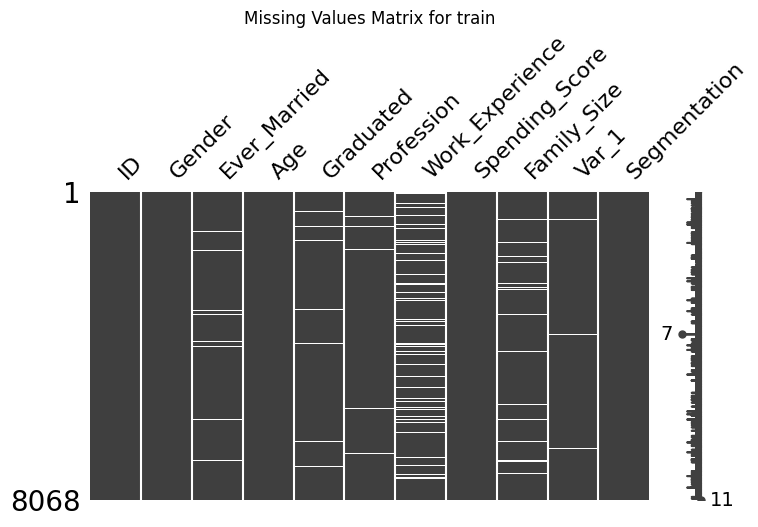

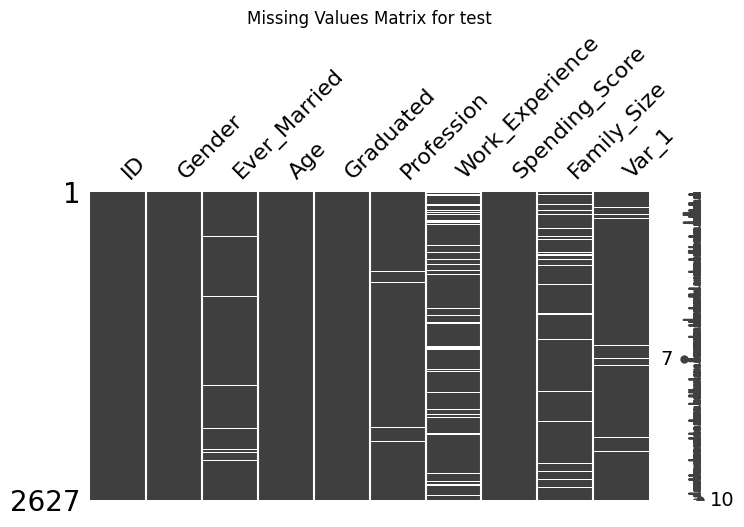

In [ ]:
msno.matrix(train, figsize=(8, 4))
plt.title('Missing Values Matrix for train')
plt.show()

msno.matrix(test, figsize=(8, 4))
plt.title('Missing Values Matrix for test')
plt.show()

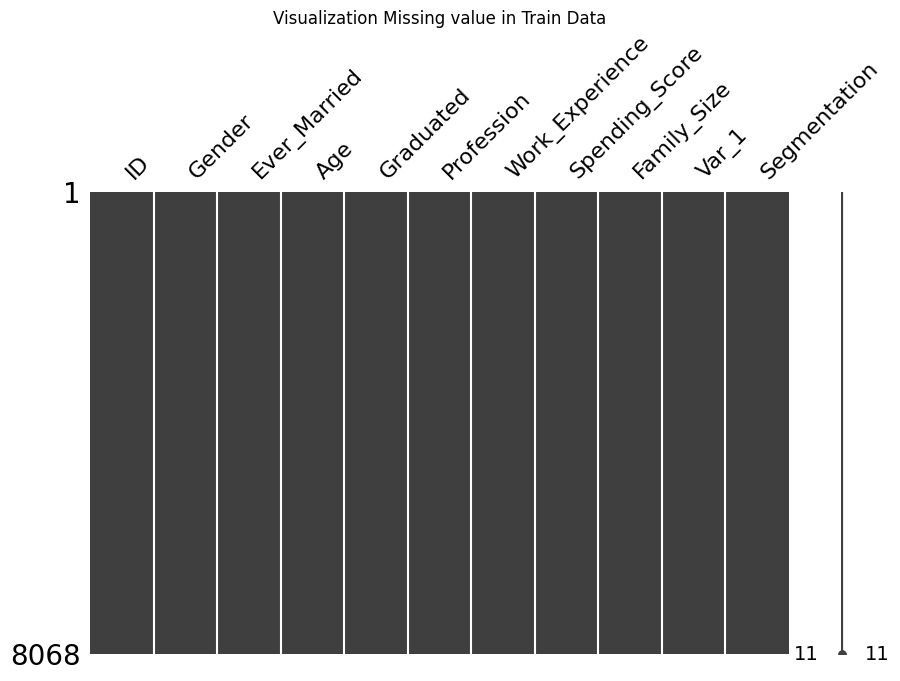

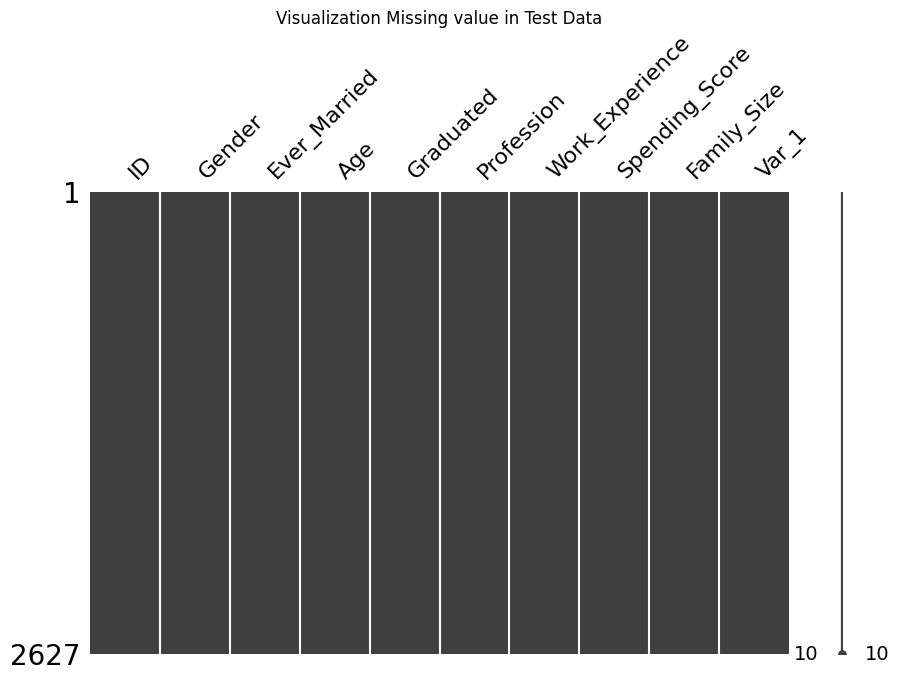

In [ ]:
# Fill the missing values of the dataset safely (no warnings)
# We use mode to handle the missing values for categorical variables
for df in [train, test]:
    categorical_columns = df.select_dtypes(include=['object']).columns
    for col in categorical_columns:
        mode_value = df[col].mode()[0]
        df[col] = df[col].fillna(mode_value)

# We use median to handle missing value for numerical variables
for df in [train, test]:
    numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns
    for col in numerical_columns:
        median_value = df[col].median()
        df[col] = df[col].fillna(median_value)

# Visualize missing values for both train and test datasets
# Train dataset visualization
msno.matrix(train, figsize=(10, 6))
plt.title('Visualization Missing value in Train Data')
plt.show()

# Test dataset visualization
msno.matrix(test, figsize=(10, 6))
plt.title('Visualization Missing value in Test Data')
plt.show()


In [ ]:
# Column definitions
categorical_cols = ["Gender", "Ever_Married", "Graduated", "Profession", "Spending_Score", "Var_1"]
numerical_cols = ["Work_Experience", "Family_Size"]

# Separation between features and target
X_train = train.drop(columns=["Segmentation"])
y_train = train["Segmentation"]

# Create a preprocessor that applies OneHotEncoder to categorical columns and StandardScaler to numerical columns
num_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),        # Gère les NaN numériques
    ("scaler", StandardScaler())                          # Mise à l’échelle standard
])

cat_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")), # Gère les NaN catégoriques
    ("encoder", OneHotEncoder(handle_unknown="ignore"))   # Encodage one-hot
])

preprocessor = ColumnTransformer(transformers=[
    ("num", num_transformer, numerical_cols),
    ("cat", cat_transformer, categorical_cols)
])

# Application of the process
X_train_prepared = preprocessor.fit_transform(X_train)
X_test_prepared = preprocessor.transform(test)

print("Shape of X_train_prepared:", X_train_prepared.shape)
print("Shape of X_test_prepared:", X_test_prepared.shape)

# Encodding of the target
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)

# OneHot encoding for keras
y_train_encoded = to_categorical(y_train_encoded)

print("Shape of y_train_encoded:", y_train_encoded.shape)
print("Classes:", label_encoder.classes_)

Shape of X_train_prepared: (8068, 27)
Shape of X_test_prepared: (2627, 27)
Shape of y_train_encoded: (8068, 4)
Classes: ['A' 'B' 'C' 'D']


# Model 1 - Best Practices Model

We are building a neural network model with 3 hidden layers using the ReLU activation function and Softmax on the output. We are also using categorical cross-entropy as the loss function and Adam optimizer.

In [ ]:
# y_train_encoded is in OneHot so we need to take the version non encoded
y_labels = np.argmax(y_train_encoded, axis=1)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_prepared,
    y_train_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_labels
)

# Conversion in the good format for TensorFlow
X_train = X_train.astype(np.float32)
X_val = X_val.astype(np.float32)

model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_prepared.shape[1],)), #First hidden layer
    Dense(32, activation='relu'), #Second hidden layer
    Dense(16, activation='relu'), #Third hidden layer
    Dense(y_train_encoded.shape[1], activation='softmax') #Output Layer
])

# Compilation
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 64)             │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 4)              │            68 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,468 (17.45 KB)

 Trainable params: 4,468 (17.45 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#Define early stopping
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

#Train the model with early stopping
history = model.fit(
    X_train_prepared,
    y_train_encoded,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/50
202/202 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.5352 - loss: 1.0680 - val_accuracy: 0.5235 - val_loss: 1.0792
Epoch 2/50
202/202 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.5450 - loss: 1.0559 - val_accuracy: 0.5304 - val_loss: 1.0833
Epoch 3/50
202/202 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.5307 - loss: 1.0693 - val_accuracy: 0.5192 - val_loss: 1.0780
Epoch 4/50
202/202 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5338 - loss: 1.0567 - val_accuracy: 0.5173 - val_loss: 1.0799
Epoch 5/50
202/202 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5543 - loss: 1.0482 - val_accuracy: 0.5198 - val_loss: 1.0826
Epoch 6/50
202/202 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5502 - loss: 1.0454 - val_accuracy: 0.5198 - val_loss: 1.0805
Epoch 7/50
202/202 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5493 - loss: 1.0446 - val_accuracy: 0.5118 - val_loss: 1.0852
Epoch 8/50
202/202 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5601 - loss: 1.0290 - val_accuracy: 0

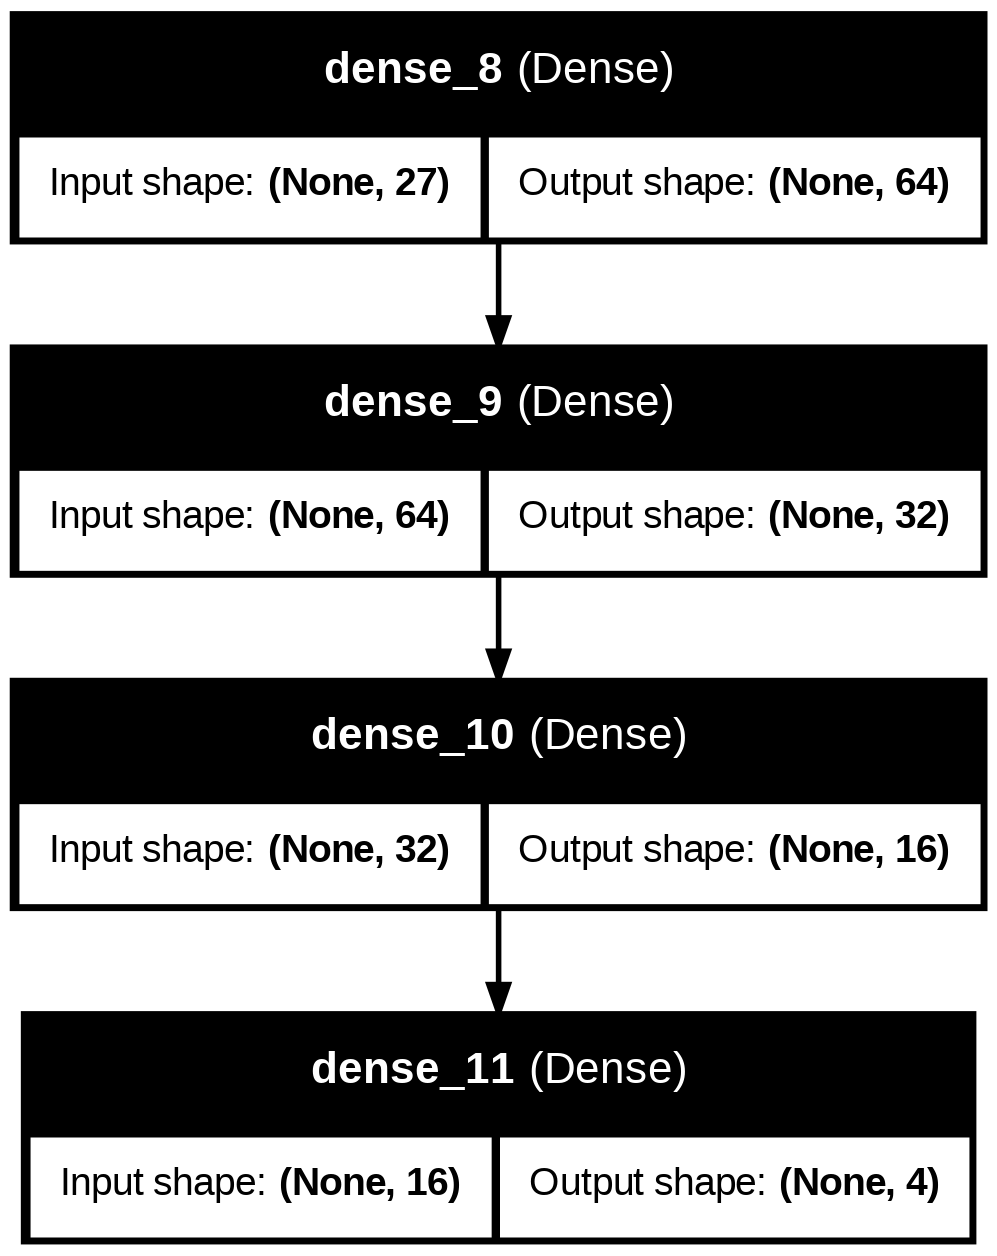

In [ ]:
#Show the model structure
plot_model(model, to_file='model_1_structure.png', show_shapes=True, show_layer_names=True)
from IPython.display import Image
Image(filename='model_1_structure.png')

In [ ]:
from sklearn.metrics import classification_report
import numpy as np

# Prediction on validation
y_val_pred = np.argmax(model.predict(X_val), axis=1)

# Conversion of y_val one-hot in number
y_val_labels = np.argmax(y_val, axis=1)

# Classification report
print(classification_report(
    y_val_labels,
    y_val_pred,
    target_names=[str(cls) for cls in label_encoder.classes_]
))

51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
              precision    recall  f1-score   support

           A       0.43      0.45      0.44       394
           B       0.44      0.38      0.41       372
           C       0.57      0.59      0.58       394
           D       0.68      0.71      0.69       454

    accuracy                           0.54      1614
   macro avg       0.53      0.53      0.53      1614
weighted avg       0.54      0.54      0.54      1614



# Model 2 - Hyperparameter Optimization Using Keras Tuner

We are using Keras Tuner to optimize the following hyperparameters: Number of hidden layers, Number of neurons in each layer, Learning rate and many more.
Set up a search space that explores different combinations of these hyperparameters. Experiment =5

In [ ]:
# Construction of the model function
def build_model(hp):
    model = Sequential()
    # Number of hidden layers : between 1 and 5
    for i in range(hp.Int('num_layers', 1, 5)):
        model.add(Dense(
            units=hp.Int(f'units_{i}', min_value=64, max_value=256, step=64),
            activation='relu'
        ))
    # output layer
    model.add(Dense(y_train.shape[1], activation='softmax'))

    # Optimizer : Adam with different learning rate
    lr = hp.Choice('learning_rate', [1e-2, 1e-3, 1e-4])
    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

In [ ]:
import keras_tuner as kt
import tensorflow as tf
# Initialisation of the Tuner
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=5,              # number of experiment
    executions_per_trial=1,
    directory='keras_tuner_dir',
    project_name='segmentation_optimization'
)

# Start of the research
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

tuner.search(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

# Recuperation of the best model
best_model = tuner.get_best_models(num_models=1)[0]
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]

print("Best hyperparameters found :")
for param, value in best_hp.values.items():
    print(f"{param}: {value}")

# Evaluation of the optimized model
val_loss, val_acc = best_model.evaluate(X_val, y_val, verbose=0)
print(f"\n Accuracy of best model : {val_acc:.4f}")

Reloading Tuner from keras_tuner_dir/segmentation_optimization/tuner0.json


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Best hyperparameters found :
num_layers: 4
units_0: 128
learning_rate: 0.001
units_1: 64
units_2: 64
units_3: 192

 Accuracy of best model : 0.5409


In [ ]:
#Evaluate the performance of the Best model on the training data
train_loss, train_accuracy = best_model.evaluate(X_train_prepared, y_train_encoded)
print(f"Best Model Training Accuracy: {train_accuracy:.4f}")
print(f"Best Model Training Loss: {train_loss:.4f}")

#Save the model for future use
best_model.save('best_model.keras')

253/253 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5399 - loss: 1.0642
Best Model Training Accuracy: 0.5450
Best Model Training Loss: 1.0613


# Model Evaluation and Performance

We evaluate both models on the training data using accuracy as the metric and
generate the classification report showing precision, recall, and F1-score for each customer segment.

In [ ]:
train_loss, train_accuracy = model.evaluate(X_train_prepared, y_train_encoded, verbose=0)
print(f"Model Training Accuracy: {train_accuracy:.4f}")
print(f"Model Training Loss: {train_loss:.4f}")

#Generate predictions on training data
train_predictions = model.predict(X_train_prepared)
train_predictions = np.argmax(train_predictions, axis=1)
train_true_labels = np.argmax(y_train_encoded, axis=1)
class_labels = label_encoder.classes_

print("\nClassification Report:")
print(classification_report(train_true_labels, train_predictions, target_names=class_labels))
print(f"Accuracy Score: {accuracy_score(train_true_labels, train_predictions):.4f}")

Model Training Accuracy: 0.5423
Model Training Loss: 1.0521
253/253 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step

Classification Report:
              precision    recall  f1-score   support

           A       0.46      0.48      0.47      1972
           B       0.43      0.38      0.41      1858
           C       0.57      0.58      0.58      1970
           D       0.67      0.69      0.68      2268

    accuracy                           0.54      8068
   macro avg       0.53      0.53      0.53      8068
weighted avg       0.54      0.54      0.54      8068

Accuracy Score: 0.5423


# Training vs. Validation Loss Plot



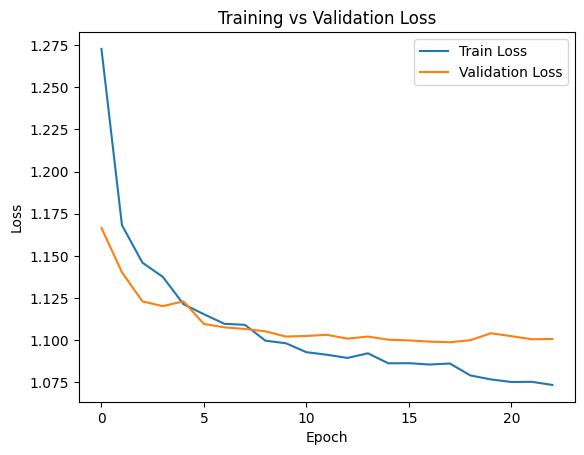

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training vs Validation Loss')
plt.show()

# Make Predictions on test.csv
For both models, we use the test.csv data (X_test) to generate predictions for the customer segments and convert the softmax output to predicted class labels (A, B, C, or D).

In [ ]:
X_test = test
X_test_prepared = preprocessor.transform(X_test)

#Make predictions
predictions_model_1 = model.predict(X_test_prepared)
predictions_best_model = best_model.predict(X_test_prepared)

#Convert softmax output to predicted class labels
predictions_model_1 = np.argmax(predictions_model_1, axis=1)
predictions_best_model = np.argmax(predictions_best_model, axis=1)

#Convert integer class labels back to original class labels
predictions_model_1 = label_encoder.inverse_transform(predictions_model_1)
predictions_best_model = label_encoder.inverse_transform(predictions_best_model)

#Print predictions
print("Model 1 Predictions:")
print(predictions_model_1)

print("\nBest Model Predictions:")
print(predictions_best_model)

83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
Model 1 Predictions:
['A' 'A' 'B' ... 'A' 'B' 'D']

Best Model Predictions:
['B' 'C' 'B' ... 'D' 'B' 'D']


In [ ]:
y_pred_model_1 = model.predict(X_train_prepared)
y_pred_best_model = best_model.predict(X_train_prepared)

y_pred_labels_model_1 = np.argmax(y_pred_model_1, axis=1)
y_pred_labels_best_model = np.argmax(y_pred_best_model, axis=1)

y_true_labels = np.argmax(y_train_encoded, axis=1)

report_model_1 = classification_report(y_true_labels, y_pred_labels_model_1, target_names=label_encoder.classes_)
report_best_model = classification_report(y_true_labels, y_pred_labels_best_model, target_names=label_encoder.classes_)

print("Model 1 Classification Report:")
print(report_model_1)

print("\nBest Model Classification Report:")
print(report_best_model)

253/253 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
253/253 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Model 1 Classification Report:
              precision    recall  f1-score   support

           A       0.46      0.48      0.47      1972
           B       0.43      0.38      0.41      1858
           C       0.57      0.58      0.58      1970
           D       0.67      0.69      0.68      2268

    accuracy                           0.54      8068
   macro avg       0.53      0.53      0.53      8068
weighted avg       0.54      0.54      0.54      8068


Best Model Classification Report:
              precision    recall  f1-score   support

           A       0.51      0.37      0.43      1972
           B       0.42      0.42      0.42      1858
           C       0.58      0.59      0.58      1970
           D       0.63      0.76      0.69      2268

    accuracy                           0.54      8068
   macro avg       0.53      0.54      0.53      8068
weighted avg       0.54      0.54    

# Confusion Matrix for Train

51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


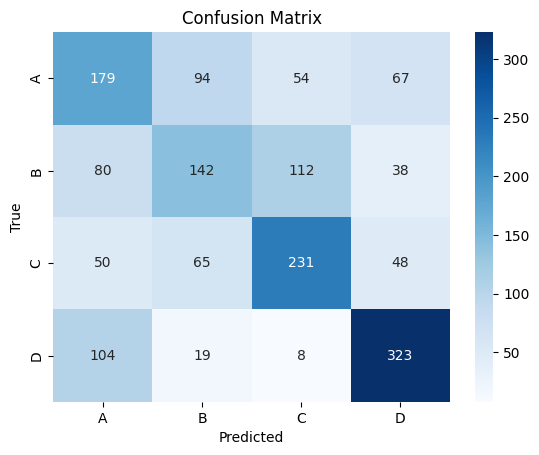

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Convertir les labels OneHot en indices ---
y_val_labels = np.argmax(y_val, axis=1)  # Labels réels

# --- 2. Prédictions du modèle sur le jeu de validation ---
y_val_pred_prob = model.predict(X_val)           # Probabilités
y_val_pred_labels = np.argmax(y_val_pred_prob, axis=1)  # Classes prédites

# --- 3. Calcul de la matrice de confusion ---
cm = confusion_matrix(y_val_labels, y_val_pred_labels)

# --- 4. Affichage avec seaborn ---
# Optionnel : noms des classes si tu les as
class_names = ['A', 'B', 'C', 'D']  # Adapter selon ton dataset

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step


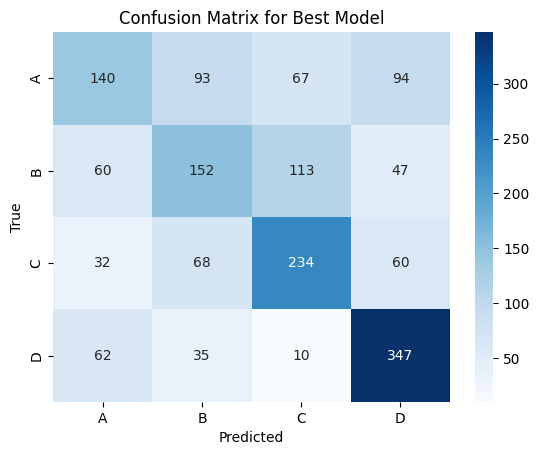

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Convertir les labels OneHot en indices ---
y_val_labels = np.argmax(y_val, axis=1)  # Labels réels

# --- 2. Prédictions sur le jeu de validation ---
y_val_pred_prob = best_model.predict(X_val)           # Probabilités
y_val_pred_labels = np.argmax(y_val_pred_prob, axis=1)  # Classes prédites

# --- 3. Calcul de la matrice de confusion ---
cm = confusion_matrix(y_val_labels, y_val_pred_labels)

# --- 4. Affichage avec seaborn ---
# Optionnel : noms des classes si tu les as
class_names = ['A', 'B', 'C', 'D']  # Si tu as utilisé un LabelEncoder pour y_train

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for Best Model')
plt.show()


# Save Predictions
We save the predictions for the test set in a CSV file in the following format: Customer ID, Predicted__Segment

In [ ]:
import numpy as np
import pandas as pd
from google.colab import drive

drive.mount('/content/drive')

# Prediction on test
y_test_pred = best_model.predict(X_test_prepared)
test_classes = np.argmax(y_test_pred, axis=1)

test_labels = label_encoder.inverse_transform(test_classes)

submission_df = pd.DataFrame({
    "Customer_ID": test["ID"],  # utilisation de la colonne ID
    "Predicted_Segment": test_labels
})

# Path to my Drive
output_path = "/content/drive/MyDrive/final_test_predictions.csv"

# Download of the cvs on Google Drive
submission_df.to_csv(output_path, index=False)
print(f" Fichier sauvegardé avec succès dans Google Drive : {output_path}")

submission_df.head()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
 Fichier sauvegardé avec succès dans Google Drive : /content/drive/MyDrive/final_test_predictions.csv


,Customer_ID,Predicted_Segment
0,458989,B
1,458994,C
2,458996,B
3,459000,A
4,459001,D


In [ ]:
!pip install nbconvert

In [ ]:
!apt-get install texlive texlive-xetex texlive-latex-extra pandoc

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
pandoc is already the newest version (2.9.2.1-3ubuntu2).
pandoc set to manually installed.
The following additional packages will be installed:
  dvisvgm fonts-droid-fallback fonts-lato fonts-lmodern fonts-noto-mono
  fonts-texgyre fonts-urw-base35 libapache-pom-java libcommons-logging-java
  libcommons-parent-java libfontbox-java libgs9 libgs9-common libidn12
  libijs-0.35 libjbig2dec0 libkpathsea6 libpdfbox-java libptexenc1 libruby3.0
  libsynctex2 libteckit0 libtexlua53 libtexluajit2 libwoff1 libzzip-0-13
  lmodern poppler-data preview-latex-style rake ruby ruby-net-telnet
  ruby-rubygems ruby-webrick ruby-xmlrpc ruby3.0 rubygems-integration t1utils
  teckit tex-common tex-gyre texlive-base texlive-binaries
  texlive-fonts-recommended texlive-latex-base texlive-latex-recommended
  texlive-pictures texlive-plain-generic tipa xfonts-encodings xfonts-utils
Suggested packages:
  fonts-noto f

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!jupyter nbconvert --to pdf "/content/drive/MyDrive/Colab Notebooks/Louis_Keller_Assignment1.ipynb"

[NbConvertApp] Converting notebook /content/drive/MyDrive/Colab Notebooks/Louis_Keller_Assignment1.ipynb to pdf
[NbConvertApp] Support files will be in Louis_Keller_Assignment1_files/
[NbConvertApp] Making directory ./Louis_Keller_Assignment1_files
[NbConvertApp] Writing 138910 bytes to notebook.tex
[NbConvertApp] Building PDF
[NbConvertApp] Running xelatex 3 times: ['xelatex', 'notebook.tex', '-quiet']
[NbConvertApp] Running bibtex 1 time: ['bibtex', 'notebook']
[NbConvertApp] WARNING | bibtex had problems, most likely because there were no citations
[NbConvertApp] PDF successfully created
[NbConvertApp] Writing 458935 bytes to /content/drive/MyDrive/Colab Notebooks/Louis_Keller_Assignment1.pdf


In [ ]:
import os
print(os.getcwd())

/content


In [ ]:
os.listdir()

['.config',
 'drive',
 'final_test_predictions.csv',
 'best_model.keras',
 'keras_tuner_dir',
 'model_1_structure.png',
 'sample_data']

In [ ]:
!ls /content/drive/MyDrive/

'A look at the statistics and development of gambling in Monmouth University.gform'
'A look at the statistics and development of gambling in Monmouth University (réponses).gsheet'
 broadcast_logs
 BroadcastLogs_2018_Q3_M8_sample.CSV
 broadcast_logs-20250313T064441Z-001.zip
 car_prices.csv
 cars_dataframe.csv
'Colab Notebooks'
'DOC072924-07292024090524 (1).pdf'
'DOC072924-07292024090524 (2).pdf'
'DOC072924-07292024090524 (3).pdf'
 DOC072924-07292024090524.pdf
'EA Oliver L2 - Louis Keller.pdf'
 Electronic_ticket.pdf
"Fiche%20de%20r%C3%A9vision%20pour%20l'%C3%A9valuation%20d'immunologie.pdf"
 final_test_predictions.csv
'Formulaire sans titre.gform'
'formulaires-changement-de-club-interactif (1).pdf'
 formulaires-changement-de-club-interactif.pdf
 home.pdf
 Outlook
'Sports Participation Form.docx'
 test.csv
 test_predictions.csv
 train.csv


In [ ]:
!find /content/drive/MyDrive/ -name "Louis_Keller_Assignment1.ipynb"

/content/drive/MyDrive/Colab Notebooks/Louis_Keller_Assignment1.ipynb


In [ ]:
!jupyter nbconvert --to pdf --output Louis_Keller_Assignment1.pdf Louis_Keller_Assignment1.ipynb

[NbConvertApp] WARNING | pattern 'Louis_Keller_Assignment1.ipynb' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_config=True]
-y
    Answer yes to any questions instead of prompting.
    Equivalent to: [--JupyterApp.answer_yes=True]


Trial 5 Complete [00h 00m 29s]
val_accuracy: 0.5140495896339417

Best val_accuracy So Far: 0.5245178937911987
Total elapsed time: 00h 01m 40s


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))



 Best Hyperparameters Found:
  units_input: 512
  dropout_input: 0.1
  num_layers: 1
  units_0: 96
  dropout_0: 0.5
  learning_rate: 0.0018049869309856735
  units_1: 160
  dropout_1: 0.5
  units_2: 128
  dropout_2: 0.30000000000000004
227/227 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

 Model 1 – Train Performance
              precision    recall  f1-score   support

           A       0.47      0.52      0.49      1814
           B       0.50      0.37      0.42      1815
           C       0.56      0.61      0.58      1814
           D       0.65      0.69      0.67      1814

    accuracy                           0.55      7257
   macro avg       0.54      0.55      0.54      7257
weighted avg       0.54      0.55      0.54      7257



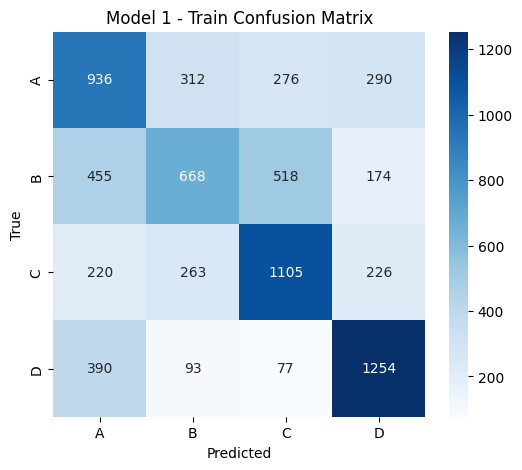


 Model 1 – Test Performance
              precision    recall  f1-score   support

           A       0.44      0.48      0.46       454
           B       0.44      0.32      0.37       453
           C       0.52      0.58      0.55       454
           D       0.62      0.66      0.64       454

    accuracy                           0.51      1815
   macro avg       0.51      0.51      0.51      1815
weighted avg       0.51      0.51      0.51      1815



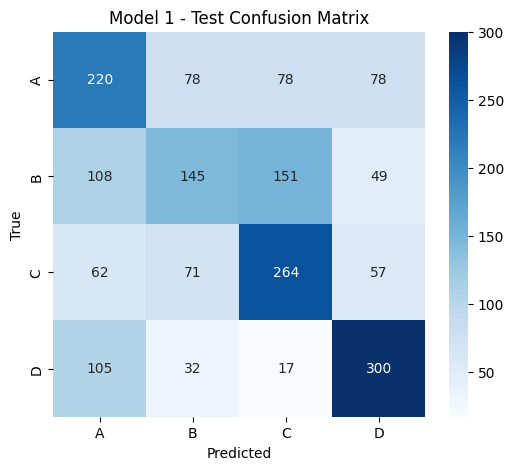

227/227 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

 Model 2 – Train Performance
              precision    recall  f1-score   support

           A       0.50      0.41      0.45      1814
           B       0.47      0.37      0.41      1815
           C       0.54      0.66      0.59      1814
           D       0.63      0.75      0.68      1814

    accuracy                           0.55      7257
   macro avg       0.54      0.55      0.53      7257
weighted avg       0.54      0.55      0.53      7257



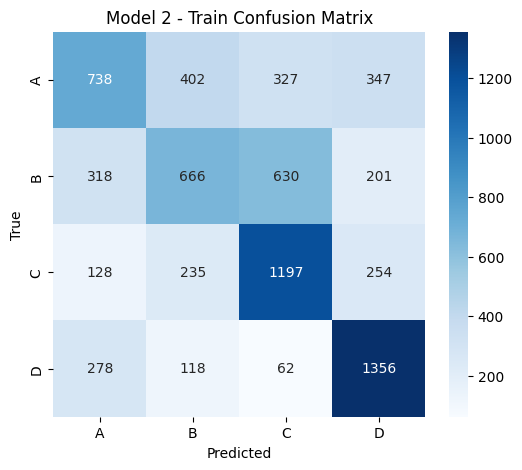


 Model 2 – Test Performance
              precision    recall  f1-score   support

           A       0.48      0.39      0.43       454
           B       0.46      0.36      0.40       453
           C       0.52      0.64      0.58       454
           D       0.60      0.71      0.65       454

    accuracy                           0.52      1815
   macro avg       0.52      0.52      0.51      1815
weighted avg       0.52      0.52      0.51      1815



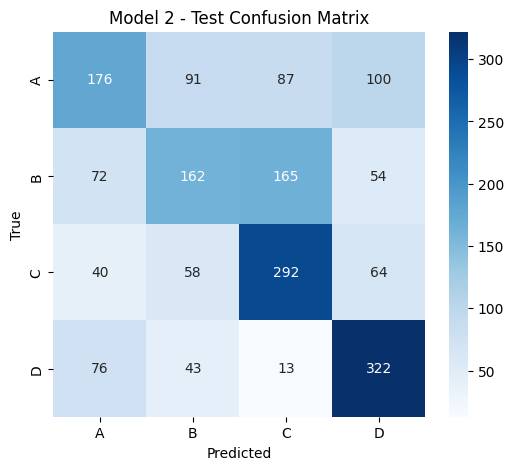

In [ ]:
# Non-Synthetic Approach

import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
import keras_tuner as kt

# Cleaning and preparing the data

categorical_cols = ["Gender", "Ever_Married", "Graduated", "Profession", "Spending_Score", "Var_1"]
numerical_cols = ["Work_Experience", "Family_Size"]

# Handling Missing values
for col in categorical_cols:
    if col in train.columns:
        mode_val = train[col].mode()[0]
        train[col] = train[col].fillna(mode_val)

for col in numerical_cols:
    if col in train.columns:
        mean_val = train[col].mean()
        train[col] = train[col].fillna(mean_val)

# One-Hot Encoding
encoder = OneHotEncoder(sparse_output=False, drop='first')
X_cat = encoder.fit_transform(train[categorical_cols])
df_cat = pd.DataFrame(X_cat, columns=encoder.get_feature_names_out(categorical_cols))

# Concatenation of categorical and numerical column
X_num = train[numerical_cols].reset_index(drop=True)
X = pd.concat([X_num, df_cat], axis=1)

# Scaling
scaler = StandardScaler()
X[numerical_cols] = scaler.fit_transform(X[numerical_cols])

# encoding of the target variable
le = LabelEncoder()
y = le.fit_transform(train["Segmentation"])

# Creation of the synthetique dataset (using SMOTE)
print("Before SMOTE :", np.bincount(y))
sm = SMOTE(random_state=42)
X_new, y_new = sm.fit_resample(X, y)
print("After SMOTE :", np.bincount(y_new))

train_new = pd.concat([pd.DataFrame(X_new, columns=X.columns),
                       pd.Series(y_new, name="Segmentation")], axis=1)

# Split train_new in train/test (80/20)
X_train, X_test, y_train_int, y_test_int = train_test_split(
    X_new, y_new, test_size=0.2, random_state=42, stratify=y_new
)

# One-Hot Encoding for Keras
y_train = to_categorical(y_train_int)
y_test = to_categorical(y_test_int)

# Model 1
model1 = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(y_train.shape[1], activation='softmax')
])

model1.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

print("\n Model 1 Training")
history1 = model1.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

# Model 2 – Keras Tuner Optimized
def build_model(hp):
    model = Sequential()
    model.add(Dense(
        units=hp.Int('units_input', 64, 512, step=64),
        activation='relu',
        input_shape=(X_train.shape[1],)
    ))
    model.add(Dropout(rate=hp.Float('dropout_input', 0.1, 0.5, step=0.1)))

    for i in range(hp.Int('num_layers', 1, 3)):
        model.add(Dense(
            units=hp.Int(f'units_{i}', 32, 256, step=32),
            activation='relu'
        ))
        model.add(Dropout(rate=hp.Float(f'dropout_{i}', 0.1, 0.5, step=0.1)))

    model.add(Dense(y_train.shape[1], activation='softmax'))

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=hp.Float('learning_rate', 1e-4, 1e-2, sampling='log')
        ),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=5,
    executions_per_trial=1,
    directory='keras_tuner_nonsynthetic',
    project_name='segmentation_tuned'
)

print("\n Model 2 Training (Keras Tuner)")
tuner.search(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=30,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

best_model = tuner.get_best_models(num_models=1)[0]
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]

print("\n Best Hyperparameters Found:")
for k, v in best_hp.values.items():
    print(f"  {k}: {v}")

# Évaluations et matrices de confusion
def plot_conf_matrix(y_true, y_pred, title):
    plt.figure(figsize=(6,5))
    sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt='d',
                cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(title)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

# Model 1
y_train_pred_1 = np.argmax(model1.predict(X_train), axis=1)
y_test_pred_1 = np.argmax(model1.predict(X_test), axis=1)

print("\n Model 1 – Train Performance")
print(classification_report(y_train_int, y_train_pred_1, target_names=le.classes_))
plot_conf_matrix(y_train_int, y_train_pred_1, "Model 1 - Train Confusion Matrix")

print("\n Model 1 – Test Performance")
print(classification_report(y_test_int, y_test_pred_1, target_names=le.classes_))
plot_conf_matrix(y_test_int, y_test_pred_1, "Model 1 - Test Confusion Matrix")

# Model 2
y_train_pred_2 = np.argmax(best_model.predict(X_train), axis=1)
y_test_pred_2 = np.argmax(best_model.predict(X_test), axis=1)

print("\n Model 2 – Train Performance")
print(classification_report(y_train_int, y_train_pred_2, target_names=le.classes_))
plot_conf_matrix(y_train_int, y_train_pred_2, "Model 2 - Train Confusion Matrix")

print("\n Model 2 – Test Performance")
print(classification_report(y_test_int, y_test_pred_2, target_names=le.classes_))
plot_conf_matrix(y_test_int, y_test_pred_2, "Model 2 - Test Confusion Matrix")
